In [42]:
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os, sys

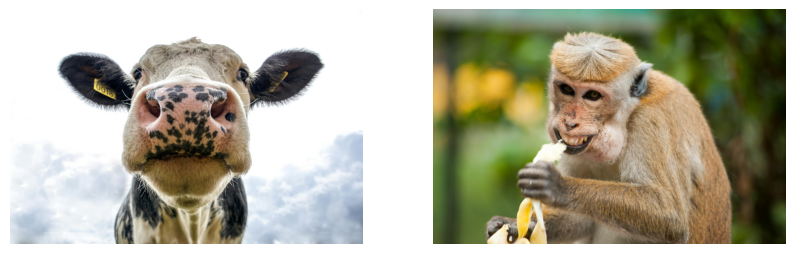

In [43]:
image = cv2.imread('assets/cow.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
path = os.path.join('assets', 'monkey.jpg')
image1 = cv2.imread(path)
image1 = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB )
fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].imshow(image)
ax[0].axis('off')
ax[1].axis('off')
ax[1].imshow(image1)


Resizing and Rotating

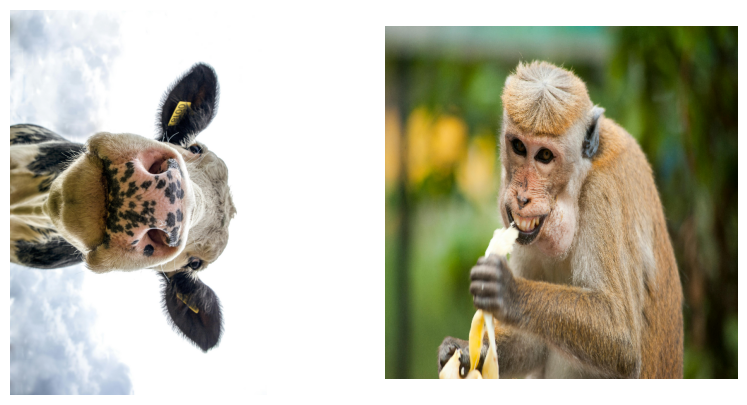

In [44]:
image = cv2.imread('assets/cow.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE)
path = os.path.join('assets', 'monkey.jpg')
image1 = cv2.imread(path)
image1 = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)
image1 = cv2.resize(image1, (500, 500))
fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].imshow(image)
ax[0].axis('off')
ax[1].axis('off')
ax[1].imshow(image1)
plt.show()


In [45]:
cv2.imwrite('assets/rotated_cow.png', image)
cv2.imwrite('assets/resized_monkey.png', image1)

True

Illustrating RGB Channels using cmaps im matplotlib

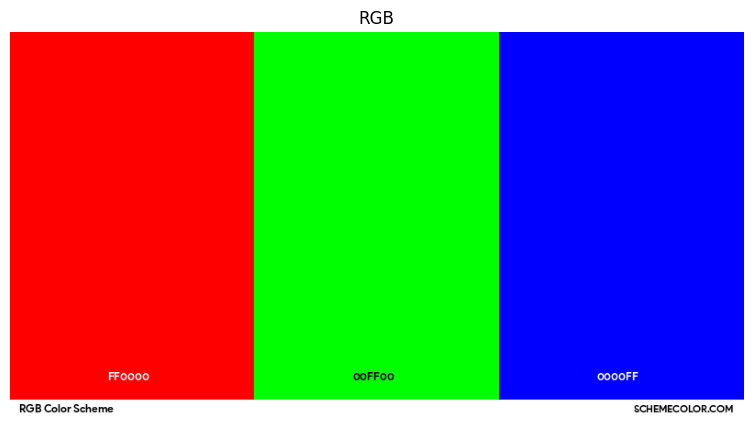

In [46]:
rgb = cv2.imread('assets/rgb-color-scheme.png')
rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)
fig, ax = plt.subplots(figsize=(10,5))
ax.imshow(rgb)
ax.set_title('RGB')
ax.axis('off')
plt.show()

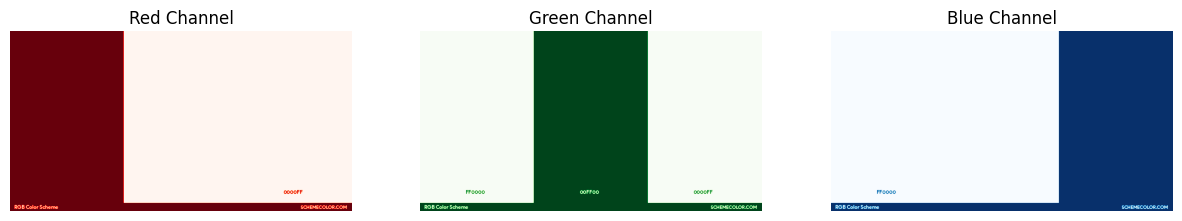

[[255 255 255 ...   0   0   0]
 [255 255 255 ...   0   0   0]
 [255 255 255 ...   0   0   0]
 ...
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]]


In [47]:
rgb = cv2.imread('assets/rgb-color-scheme.png')
rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)
fig, ax = plt.subplots(1, 3, figsize=(15,10))
ax[0].imshow(rgb[:,:,0], cmap='Reds')
ax[0].axis('off')
ax[0].set_title('Red Channel')
ax[1].axis('off')
ax[1].imshow(rgb[:,:,1], cmap='Greens')
ax[1].set_title('Green Channel')
ax[2].axis('off')
ax[2].imshow(rgb[:,:,2], cmap='Blues')
ax[2].set_title('Blue Channel')
plt.show()
print(rgb[:,:,0])

Cropping images, replacing parts, and adding masks

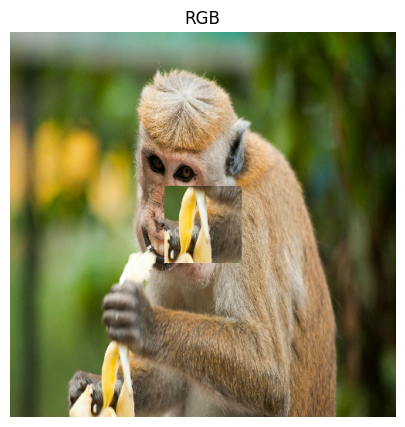

In [48]:
banana = image1[400:500, 100:200]
image1[200:300, 200:300] = banana
#image1 = cv2.cvtColor(image1, cv2.COLOR_RGB2RGBA)
#image1[:,:,3] = 0
#image1[200:300, 200:300, 3] = 255
fig, ax = plt.subplots(figsize=(10,5))
ax.imshow(image1)
ax.set_title('RGB')
ax.axis('off')
plt.show()

In [49]:
print(image1[200,200])

[ 85 107  45]


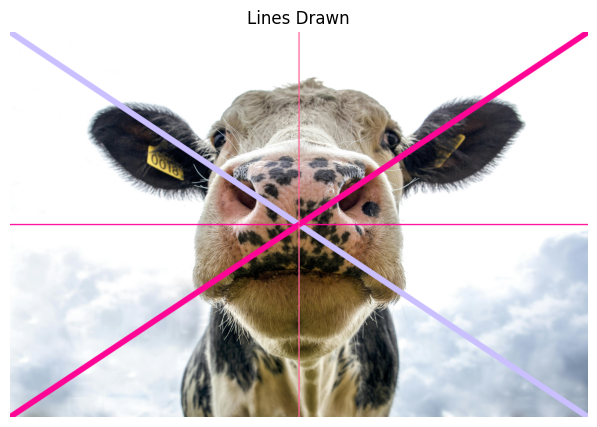

In [50]:
image = cv2.cvtColor(cv2.imread('assets/cow.jpg'), cv2.COLOR_BGR2RGB)
img = cv2.line(image, (0,0), (len(image[0]), len(image)), (203,192,255), 50)
img = cv2.line(img, (0, len(img)), (len(img[0]), 0), (255, 5, 150), 50)
img = cv2.line(img, (int(len(img[0])/2), 0), (int(len(img[0])/2), len(img)), (255, 100, 150), 10)
img = cv2.line(img, (0, int(len(img)/2)), (len(img[0]), int(len(img)/2)), (255, 5, 150), 10)
fig, ax = plt.subplots(figsize=(10,5))
ax.imshow(img)
ax.set_title('Lines Drawn')
ax.axis('off')
plt.show()

Drawing Shapes and Text on Images

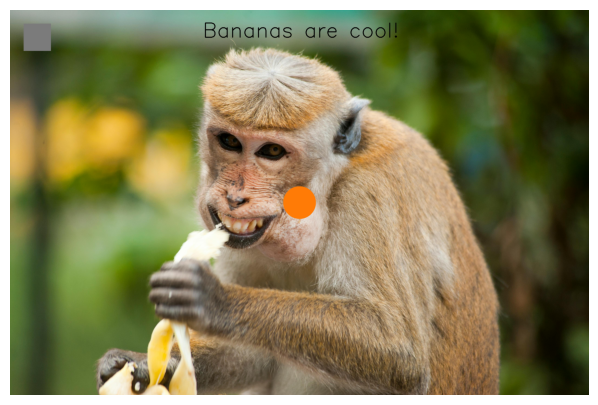

In [51]:
image = cv2.cvtColor(cv2.imread('assets/monkey.jpg'), cv2.COLOR_BGR2RGB)
img = cv2.rectangle(image, (100,100), (300,300), (123,123,123), -1) #-1 to fill
img = cv2.circle(img, (len(img[0])//2, len(img)//2), 120, (255,123,6), -1)
img = cv2.putText(img, 'Bananas are cool!', (len(img)//2, 200), cv2.FONT_ITALIC, 5, (0,0,0), 5, cv2.LINE_AA)
fig, ax = plt.subplots(figsize=(10,5))
ax.imshow(img)
ax.axis('off')
plt.show()

Color Detection

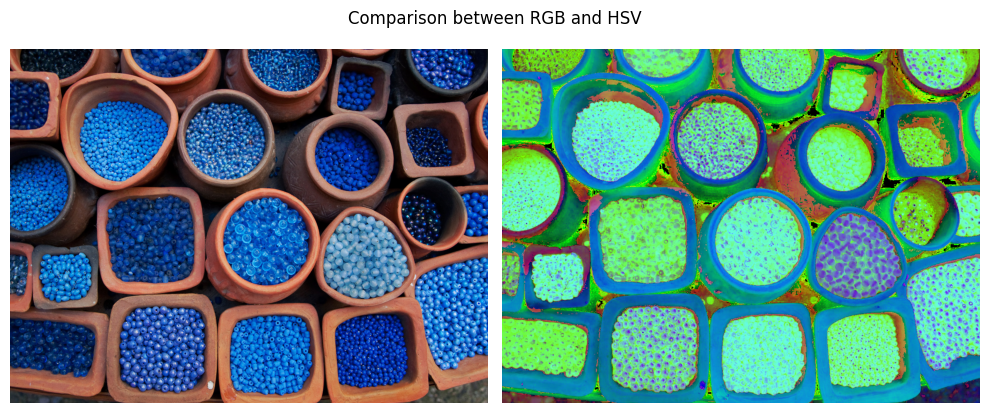

In [52]:
#Converting to HSV (Hue Saturation and Brightness)
image = cv2.imread('assets/blue_image.png', -1)
image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[1].imshow(image)
ax[0].imshow(cv2.cvtColor(cv2.imread('assets/blue_image.png', -1), cv2.COLOR_BGR2RGB))
ax[0].axis('off')
ax[1].axis('off')
#ax[0].set_title('RGB')
#ax[1].set_title('HSV')
plt.suptitle('Comparison between RGB and HSV', y=0.9)
plt.tight_layout()
plt.show()

In [53]:
#Manual approach to find HSV Pixel for upper bound of blue (dark blue)
bgr_pixel = np.array([[[255,0,0]]], dtype=np.uint8)
hsv_pixel = cv2.cvtColor(bgr_pixel, cv2.COLOR_BGR2HSV)
print(hsv_pixel[0][0])

[120 255 255]


In [54]:
upper = hsv_pixel[0][0]
lower = np.array([100,150,0], dtype=np.uint8)

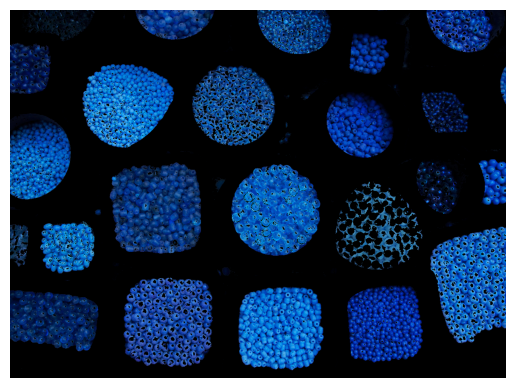

In [55]:
#Creating and applying a mask to only get pixels with blue color
mask = cv2.inRange(image, lower, upper)
image = cv2.cvtColor(image, cv2.COLOR_HSV2RGB)
result = cv2.bitwise_and(image, image, mask=mask)   #applying mask using bitwise operations (and)

fig, ax = plt.subplots()
ax.imshow(result)
ax.axis('off')
plt.show()

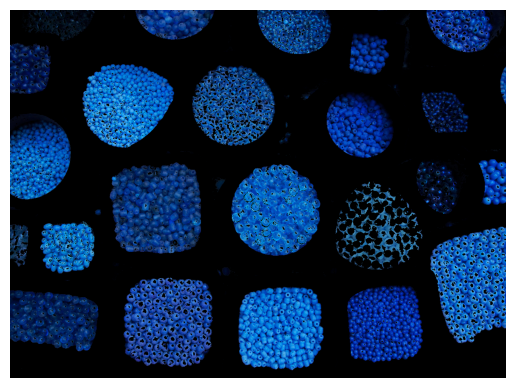

In [56]:
image = cv2.cvtColor(image, cv2.COLOR_RGB2RGBA) #applying the mask by using the alpha channel
image[:,:,3] = mask
fig, ax = plt.subplots()
ax.imshow(result)
ax.axis('off')
plt.show()

Corner Detection

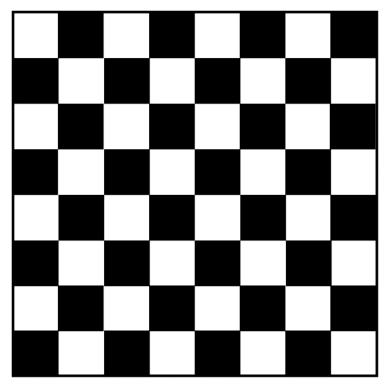

In [57]:
#using an image of a chessboard for corner detection using the Shi-Tomasi method
image = cv2.imread('assets/chess.jpg', 2)
#image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
image = image[25:image.shape[0]-25, 25: image.shape[1]-25] #Cropping image to omit text
fig, ax = plt.subplots()
ax.imshow(image, cmap='gray')
ax.axis('off')
plt.show()

In [58]:
corners = cv2.goodFeaturesToTrack(image, 100, 0.6, 50)
corners = np.array(corners, dtype=np.int16)

In [59]:
#Coloring image to show colored circles
image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

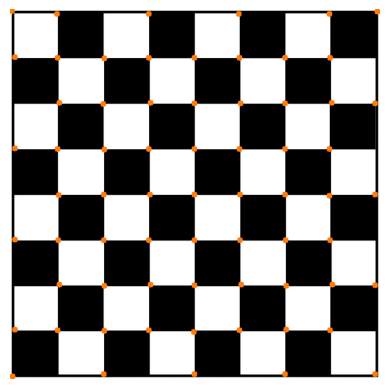

In [60]:
#Circling the corners in the image
for corner in corners:
    x, y = corner.flatten()

    cv2.circle(image, (x,y), 5, (255,123,10), -1)
fig, ax = plt.subplots()
ax.imshow(image)
ax.axis('off')
plt.show()

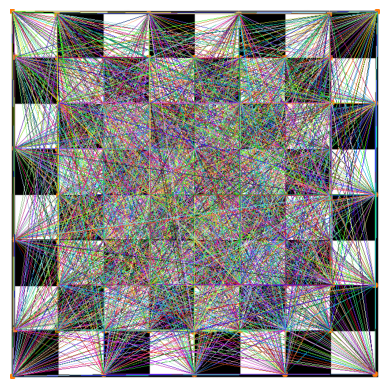

In [61]:
#Drawing random colored lines between corners
for i in range(len(corners)):
    for j in range(i+1, len(corners)):
        color = np.random.randint(0, 255, 3, np.int16)
        color = map(lambda x: int(x), color)
        color = tuple(color)
        cv2.line(image, tuple(corners[i].flatten()), tuple(corners[j].flatten()), color, 1)

fig, ax = plt.subplots()
ax.imshow(image)
ax.axis('off')
plt.show()

Object Detection (Template Matching)

In [62]:
image = cv2.imread('assets/stationary.png')
image.shape

(1068, 1600, 3)

In [63]:
stapler = image[60:160, 900:1200]   #Cropping a stapler from the image
pen = image[685:725, 18:310]    #Cropping out a pen from the image
cv2.imwrite('assets/stapler.jpg', stapler)
cv2.imwrite('assets/pen.jpg', pen)

True

In [64]:
#Converting everything to grayscale
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
stapler = cv2.cvtColor(stapler, cv2.COLOR_BGR2GRAY)
pen = cv2.cvtColor(pen, cv2.COLOR_BGR2GRAY)

Detecting the stapler in the base image using several methods from OpenCV

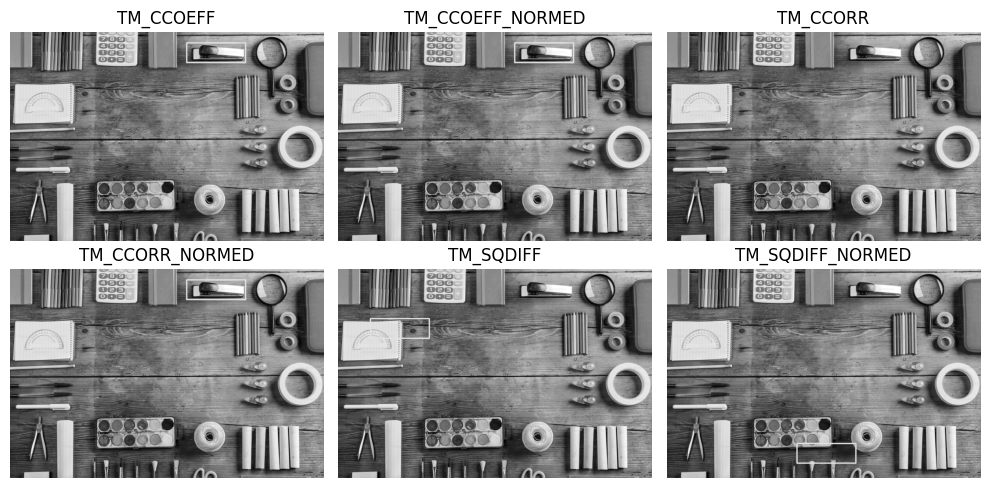

In [65]:
#Template matching methods
methods = ['TM_CCOEFF', 'TM_CCOEFF_NORMED', 'TM_CCORR', 'TM_CCORR_NORMED', 'TM_SQDIFF', 'TM_SQDIFF_NORMED']
fig, ax = plt.subplots(2, 3, figsize=(10,5))
i = 0
axes = ax.ravel()
for method in methods:
    img = image.copy()
    meth = getattr(cv2, method)
    result = cv2.matchTemplate(img, stapler, meth)
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)
    if method in [cv2.TM_SQDIFF, cv2.TM_SQDIFF_NORMED]:
        location = min_loc
    else:
        location = max_loc
    cv2.rectangle(img, location, (location[0]+stapler.shape[1], location[1]+stapler.shape[0]), 225, 5)
    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(method)
    i += 1
plt.tight_layout()
plt.show()

Face and Eye Detection (Haar-cascade classifiers)

In [66]:
#Loading classifiers
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

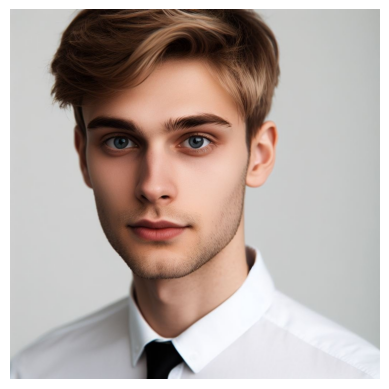

In [67]:
image = cv2.imread('assets/face.jpg') #loading
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) #converting to grayscale
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
fig, ax = plt.subplots()
ax.imshow(image)
ax.axis('off')
plt.show()

In [68]:
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.05, minNeighbors=5)
for face in faces:  #face: (x,y,w,h)
    x, y, w, h = face
    cv2.rectangle(image, (x, y), (x+w, y+h), (200,123,100), 5)
    face_square = gray[y:y+h, x:x+w]
    face_square_color = image[y:y+h, x:x+w]
    eyes = eye_cascade.detectMultiScale(face_square, 1.05, 5)
    for eye in eyes:  #face: (x,y,w,h)
        ex, ey, ew, eh = eye
        cv2.rectangle(face_square_color, (ex, ey), (ex+ew, ey+eh), (255, 0 ,100), 5)


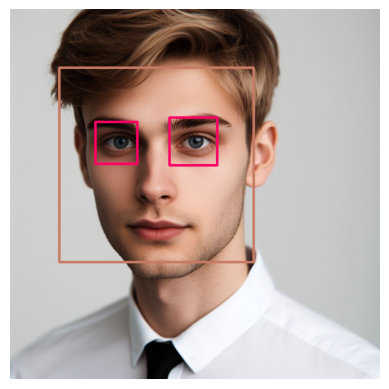

In [69]:
fig, ax = plt.subplots()
ax.imshow(image)
ax.axis('off')
plt.show()